<a href="https://colab.research.google.com/github/ThayseBachmeyer/ProcessamentoSinaisI/blob/main/Aula%2003/C%C3%B3digos/aula0409.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Código utilizado na questão 1

In [ ]:
# n°1

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

num = np.array([1,0,0.49,0,0,0,0.2401,0,-0.0576,0,-0.0282,0,-0.0138])
den = np.array([1])

freq, fase = signal.freqz(num, den, worN=512)
freq_norm = freq/(2*np.pi)

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
magnitude_db = 20 * np.log10(np.maximum(np.abs(fase), 1e-10))
plt.plot(freq_norm, magnitude_db, 'b')
plt.title('Resposta em Frequência do Sistema')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

plt.subplot(2, 1, 2)
faserad = np.angle(fase)
plt.plot(freq_norm, faserad, 'g')
plt.ylabel('Fase (radianos)')
plt.xlabel('Frequência Normalizada')
plt.grid(True)
plt.tight_layout()
plt.show()

zero, polo, ganho = signal.tf2zpk(num, den)

plt.figure(figsize=(10, 8))
ax = plt.subplot(111)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', label='Círculo Unitário')

plt.scatter(np.real(zero), np.imag(zero), s=50, marker='o', facecolors='none', edgecolors='b', label='Zeros')
plt.scatter(np.real(polo), np.imag(polo), s=50, marker='x', color='r', label='Polos')

plt.title('Diagrama de Polos e Zeros')
plt.xlabel('Eixo Real')
plt.ylabel('Eixo Imaginário')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.axis('equal')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Código utilizado na questão 2


In [ ]:
# n°2

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

num = np.array([1,0,0.49,0,0,0,0.2401,0,-0.0576,0,-0.0282,0,-0.0138])
den = np.array([1])

handel = "https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Aula%2003/Dados/handel.wav"
nome_handel = "handel.wav"

!wget -q -O {nome_handel} {handel}

fs, x = wavfile.read(nome_handel)
if len(x.shape) > 1:
    x = x[:, 0]

x = x / np.max(np.abs(x))
y = signal.lfilter(num, den, x)
y = y / np.max(np.abs(y))

N = len(x)
X_fft = np.fft.fft(x)
Y_fft = np.fft.fft(y)

frequencias = np.fft.fftfreq(N, 1/fs)
metade = N // 2
freqs_positivas = frequencias[:metade]

Y_mag_db = 20 * np.log10(np.maximum(np.abs(Y_fft[:metade]), 1e-10))

tempo = np.arange(N) / fs
plt.subplot(2, 1, 1)
plt.plot(tempo, y)
plt.title('Sinais no Domínio do Tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freqs_positivas, Y_mag_db)
plt.title('Espectro de Frequência (Magnitude)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim([0, fs/2])
plt.grid(True)

plt.tight_layout()
plt.show()

## Código utilizado na questão 3

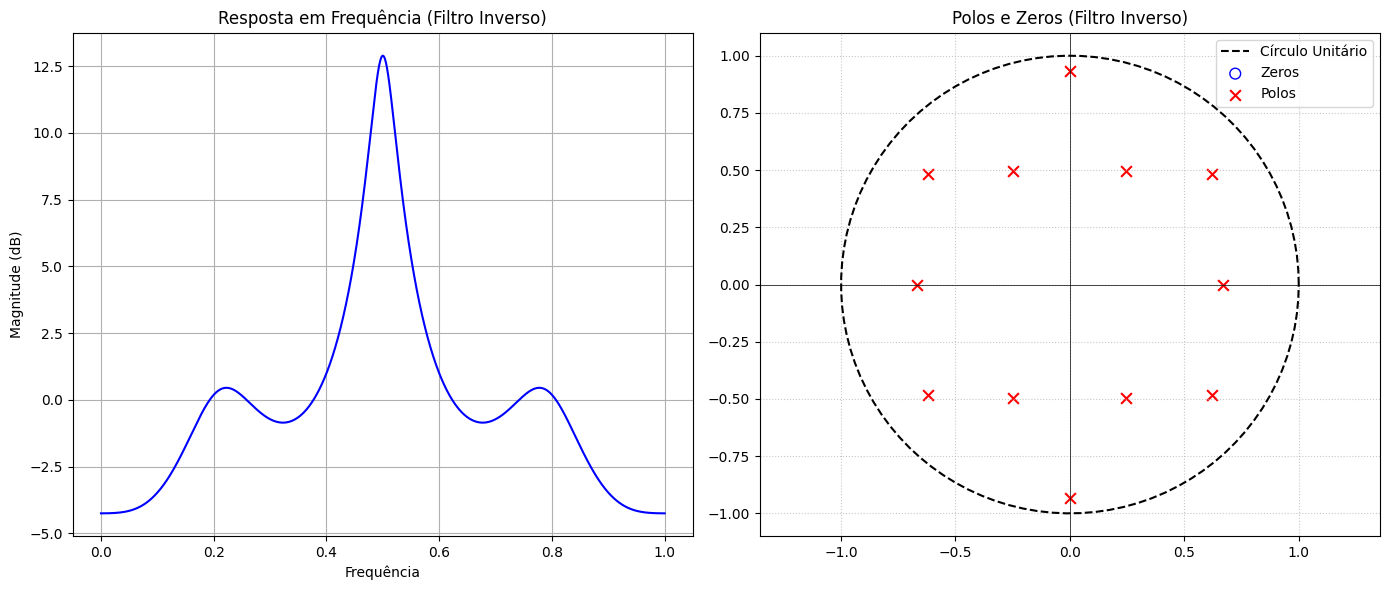

In [10]:
#n° 3

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

num = np.array([1,0,0.49,0,0,0,0.2401,0,-0.0576,0,-0.0282,0,-0.0138])
den = np.array([1])

handel = "https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Aula%2003/Dados/handel.wav"
nome_handel = "handel.wav"

!wget -q -O {nome_handel} {handel}

fs, x = wavfile.read(nome_handel)
if len(x.shape) > 1:
    x = x[:, 0]

x = x / np.max(np.abs(x))
y = signal.lfilter(num, den, x)
y = y / np.max(np.abs(y))

num_inv = den
den_inv = num

x_recuperado = signal.lfilter(num_inv, den_inv, y)
x_norm = x / np.max(np.abs(x))
x_rec_norm = x_recuperado / np.max(np.abs(x_recuperado))

w_inv, h_freq_inv = signal.freqz(num_inv, den_inv, worN=8000)
zeros_inv, polos_inv, _ = signal.tf2zpk(num_inv, den_inv)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
magnitude_inv_db = 20 * np.log10(np.maximum(np.abs(h_freq_inv), 1e-10))
plt.plot(w_inv / np.pi, magnitude_inv_db, 'b')
plt.title('Resposta em Frequência (Filtro Inverso)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Frequência')
plt.grid(True)

plt.subplot(1, 2, 2)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', label='Círculo Unitário')
plt.scatter(np.real(zeros_inv), np.imag(zeros_inv), s=60, facecolors='none', edgecolors='b', label='Zeros')
plt.scatter(np.real(polos_inv), np.imag(polos_inv), s=60, marker='x', color='r', label='Polos')
plt.title('Polos e Zeros (Filtro Inverso)')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.axis('equal')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()